# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## Task 1.1: Nasdaq Multi-Feature Extension

This section implements stock price prediction using multiple features (Low, High, Open, Close, Adjusted Close, Volume) instead of relying solely on the Open price. The model uses a 30-day sliding window to predict the next day's Open price.


In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [156]:
data_appl = pd.read_csv('data/AAPL.csv')

In [157]:
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [158]:
data_appl.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 579.3 KB


In [159]:
df = data_appl
feature_columns = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
num_features = len(feature_columns)

X_data = []
y_data = []
window_size = 30

for i in range(1, len(df) - window_size - 1):
    data_feature = []
    data_label = []

    for j in range(window_size):
        data_feature.append(df[feature_columns].iloc[i + j].values)

    data_label.append(df['Open'].iloc[i + window_size])

    X_data.append(np.array(data_feature))
    y_data.append(np.array(data_label))


In [160]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Shape of training set: ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ", X_test.shape)
print("Number of features: ", X_train.shape[2])

Shape of training set:  (6756, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:  (2112, 30, 6)
Number of features:  6


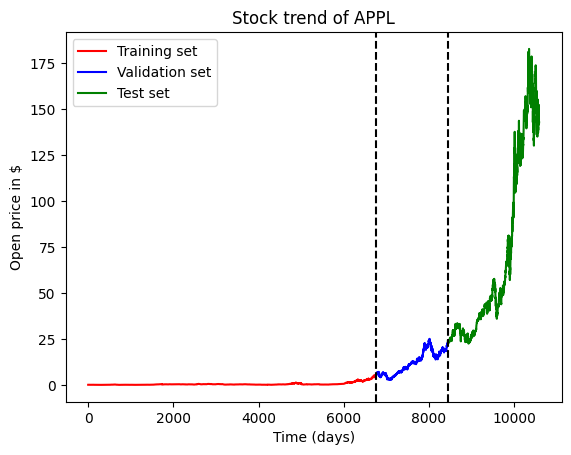

In [161]:
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

size_train = X_train.shape[0]
size_val = X_val.shape[0]
size_test = X_test.shape[0]

ax = df_plot.iloc[:size_train,1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [162]:
def normalize_multifeature(X, y):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom

        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

X_train_norm, y_train_norm = normalize_multifeature(X_train, y_train)
X_val_norm, y_val_norm = normalize_multifeature(X_val, y_val)

In [163]:
model = tf.keras.Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2.9091 - mse: 2.9091 - val_loss: 0.1981 - val_mse: 0.1981
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1778 - mse: 0.1778 - val_loss: 0.1389 - val_mse: 0.1389
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1410 - mse: 0.1410 - val_loss: 0.0896 - val_mse: 0.0896
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0769 - mse: 0.0769 - val_loss: 0.0564 - val_mse: 0.0564
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0475 - mse: 0.0475 - val_loss: 0.0305 - val_mse: 0.0305


In [164]:
X_test_norm, y_test_norm = normalize_multifeature(X_test, y_test)
y_pred_norm = model.predict(X_test_norm)
print("MSE on the test set: ", mean_squared_error(y_pred_norm, y_test_norm))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE on the test set:  0.03422575585354127


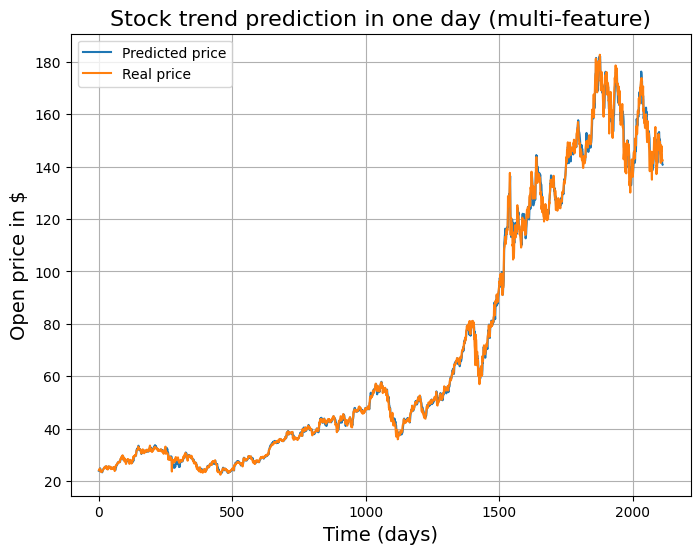

In [165]:
y_pred_denorm = y_pred_norm.copy()
for i in range(0, len(y_pred_denorm)):
    open_min = np.min(X_test[i, :, 1])
    open_max = np.max(X_test[i, :, 1])
    y_pred_denorm[i] = y_pred_norm[i] * (open_max - open_min) + open_min

plt.figure(figsize=(8, 6))
plt.plot(y_pred_denorm, label='Predicted price')
plt.plot(y_test, label='Real price')
plt.title('Stock trend prediction in one day (multi-feature)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

## Task 1.2: Nasdaq k-th Day Forecast

This section implements the k-th day forecast, predicting the stock price on the k-th day ahead instead of just the next day.

In [166]:
def prepare_data_k(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        data_label.append(df['Open'].iloc[i + window_size + k - 1])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [167]:
def train_k(k):
    X_k, y_k = prepare_data_k(df, feature_columns, window_size, k)
    
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, shuffle=False)
    X_train_k, X_val_k, y_train_k, y_val_k = train_test_split(X_train_k, y_train_k, test_size=0.2, shuffle=False)
    
    print(f"Training set: {X_train_k.shape[0]}, Val: {X_val_k.shape[0]}, Test: {X_test_k.shape[0]}")
    
    X_train_norm_k, y_train_norm_k = normalize_multifeature(X_train_k, y_train_k)
    X_val_norm_k, y_val_norm_k = normalize_multifeature(X_val_k, y_val_k)
    X_test_norm_k, y_test_norm_k = normalize_multifeature(X_test_k, y_test_k)
    
    model_k = tf.keras.Sequential()
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
    model_k.add(MaxPooling1D(pool_size=2))
    model_k.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model_k.add(MaxPooling1D(2))
    model_k.add(Flatten())
    model_k.add(Dense(100, activation='relu'))
    model_k.add(Dense(1))
    
    model_k.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
    history_k = model_k.fit(X_train_norm_k, y_train_norm_k, validation_data=(X_val_norm_k, y_val_norm_k), epochs=5, batch_size=512, verbose=1)
    
    y_pred_norm_k = model_k.predict(X_test_norm_k)
    mse_k = mean_squared_error(y_pred_norm_k, y_test_norm_k)
    
    y_pred_denorm_k = y_pred_norm_k.copy()
    for i in range(len(y_pred_denorm_k)):
        open_min = np.min(X_test_k[i, :, 1])
        open_max = np.max(X_test_k[i, :, 1])
        y_pred_denorm_k[i] = y_pred_norm_k[i] * (open_max - open_min) + open_min
    
    return {
        'mse_norm': mse_k,
        'y_pred_denorm': y_pred_denorm_k,
        'y_test': y_test_k,
        'model': model_k,
        'history': history_k
    }

In [168]:
k_values = [1, 3, 5, 7]
results = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Training model for k={k} day ahead prediction")
    print('='*50)
    
    results[k] = train_k(k) 
    print(f"MSE on test set (k={k}): {results[k]["mse_norm"]}")


Training model for k=1 day ahead prediction
Training set: 6756, Val: 1690, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 1.4468 - mse: 1.4468 - val_loss: 0.1611 - val_mse: 0.1611
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1239 - mse: 0.1239 - val_loss: 0.0701 - val_mse: 0.0701
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0542 - mse: 0.0542 - val_loss: 0.0298 - val_mse: 0.0298
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0259 - mse: 0.0259 - val_loss: 0.0219 - val_mse: 0.0219
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0190 - mse: 0.0190 - val_loss: 0.0171 - val_mse: 0.0171
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=1): 0.01820325191127891

Training model for k=3 day ahead prediction
Training set: 6755, Val: 1689, Test: 2112
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.6629 - mse: 1.6629 - val_loss: 0.2240 - val_mse: 0.2240
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2238 - mse: 0.2238 - val_loss: 0.1815 - val_mse: 0.1815
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1721 - mse: 0.1721 - val_loss: 0.1272 - val_mse: 0.1272
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1331 - mse: 0.1331 - val_loss: 0.0981 - val_mse: 0.0981
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1012 - mse: 0.1012 - val_loss: 0.0685 - val_mse: 0.0685
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE on test set (k=3): 0.07275717134771911

Training model for k=5 day ahead prediction
Training set: 6754, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.3298 - mse: 1.3298 - val_loss: 0.2910 - val_mse: 0.2910
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2923 - mse: 0.2923 - val_loss: 0.2501 - val_mse: 0.2501
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2506 - mse: 0.2506 - val_loss: 0.1685 - val_mse: 0.1685
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1766 - mse: 0.1766 - val_loss: 0.1291 - val_mse: 0.1291
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1424 - mse: 0.1424 - val_loss: 0.1158 - val_mse: 0.1158
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=5): 0.11498673428059246

Training model for k=7 day ahead prediction
Training set: 6752, Val: 1689, Test: 2111
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.1850 - mse: 1.1850 - val_loss: 0.3509 - val_mse: 0.3509
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3550 - mse: 0.3550 - val_loss: 0.2957 - val_mse: 0.2957
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3400 - mse: 0.3400 - val_loss: 0.2655 - val_mse: 0.2655
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2862 - mse: 0.2862 - val_loss: 0.1916 - val_mse: 0.1916
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2187 - mse: 0.2187 - val_loss: 0.1847 - val_mse: 0.1847
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE on test set (k=7): 0.18756581338470502


In [169]:
print("\n=== Task 1.2 Summary: k-th Day Forecast ===")
all_mse = [results[k]['mse_norm'] for k in k_values]
for k, mse in zip(k_values, all_mse):
    print(f"k={k}: MSE = {mse:.6f}")


=== Task 1.2 Summary: k-th Day Forecast ===
k=1: MSE = 0.018203
k=3: MSE = 0.072757
k=5: MSE = 0.114987
k=7: MSE = 0.187566


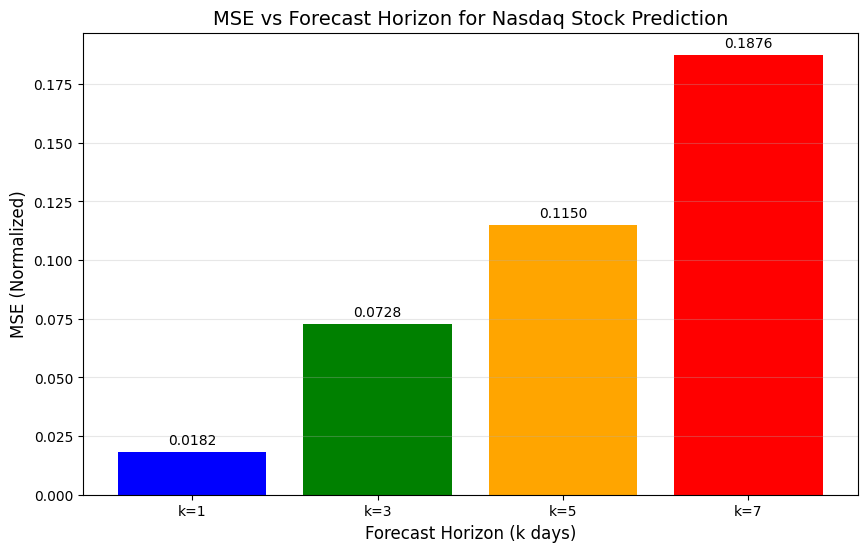

In [170]:
plt.figure(figsize=(10, 6))
bars = plt.bar([f'k={k}' for k in k_values], all_mse, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Forecast Horizon (k days)', fontsize=12)
plt.ylabel('MSE (Normalized)', fontsize=12)
plt.title('MSE vs Forecast Horizon for Nasdaq Stock Prediction', fontsize=14)
plt.grid(axis='y', alpha=0.3)
for bar, mse in zip(bars, all_mse):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{mse:.4f}', ha='center', va='bottom', fontsize=10)
plt.show()

## Task 1.3: Nasdaq k Days Forecast (Multi-Step)

This section implements predicting k consecutive days ahead in a single model. Unlike Task 1.2 which trains separate models for each forecast horizon, Task 1.3 trains one model to predict all k days simultaneously.


In [171]:
def prepare_data_multistep(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        for day in range(k):
            data_label.append(df['Open'].iloc[i + window_size + day])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [172]:
def normalize_multifeature_multi(X, y, k):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        
        for day in range(k):
            open_min = np.min(X[i, :, 1])
            open_max = np.max(X[i, :, 1])
            open_denom = open_max - open_min
            if open_denom == 0:
                y_norm[i, day] = 0
            else:
                y_norm[i, day] = (y[i, day] - open_min) / open_denom
    
    return X_norm, y_norm

In [173]:
k_multistep = 7
print(f"\n{'='*50}")
print(f"Training multi-step model for k={k_multistep} consecutive days")
print('='*50)

X_multi, y_multi = prepare_data_multistep(df, feature_columns, window_size, k_multistep)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, shuffle=False)
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(X_train_m, y_train_m, test_size=0.2, shuffle=False)

print(f"Training set: {X_train_m.shape[0]}, Val: {X_val_m.shape[0]}, Test: {X_test_m.shape[0]}")
print(f"Input shape: {X_train_m.shape}")
print(f"Output shape (k={k_multistep}): {y_train_m.shape}")

X_train_norm_m, y_train_norm_m = normalize_multifeature_multi(X_train_m, y_train_m, k_multistep)
X_val_norm_m, y_val_norm_m = normalize_multifeature_multi(X_val_m, y_val_m, k_multistep)
X_test_norm_m, y_test_norm_m = normalize_multifeature_multi(X_test_m, y_test_m, k_multistep)


Training multi-step model for k=7 consecutive days
Training set: 6752, Val: 1689, Test: 2111
Input shape: (6752, 30, 6)
Output shape (k=7): (6752, 7)


In [174]:
model_multi = tf.keras.Sequential()
model_multi.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, num_features), padding='same'))
model_multi.add(MaxPooling1D(pool_size=2))
model_multi.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_multi.add(MaxPooling1D(2))
model_multi.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_multi.add(MaxPooling1D(2))
model_multi.add(Flatten())
model_multi.add(Dense(100, activation='relu'))
model_multi.add(Dense(k_multistep))

model_multi.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_multi = model_multi.fit(X_train_norm_m, y_train_norm_m, validation_data=(X_val_norm_m, y_val_norm_m), epochs=5, batch_size=512, verbose=1)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.3345 - mse: 0.3345 - val_loss: 0.1587 - val_mse: 0.1587
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1363 - mse: 0.1363 - val_loss: 0.0942 - val_mse: 0.0942
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1106 - mse: 0.1106 - val_loss: 0.0875 - val_mse: 0.0875
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1030 - mse: 0.1030 - val_loss: 0.1006 - val_mse: 0.1006
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1031 - mse: 0.1031 - val_loss: 0.0894 - val_mse: 0.0894


In [175]:
y_pred_norm_m = model_multi.predict(X_test_norm_m)
mse_multi = mean_squared_error(y_pred_norm_m, y_test_norm_m)
print(f"\nOverall MSE (k={k_multistep} multi-step): {mse_multi}")

mse_per_day = []
for day in range(k_multistep):
    mse_day = mean_squared_error(y_pred_norm_m[:, day], y_test_norm_m[:, day])
    mse_per_day.append(mse_day)
    print(f"Day {day+1} MSE: {mse_day:.6f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Overall MSE (k=7 multi-step): 0.09171379625826995
Day 1 MSE: 0.018724
Day 2 MSE: 0.041350
Day 3 MSE: 0.064922
Day 4 MSE: 0.090587
Day 5 MSE: 0.116991
Day 6 MSE: 0.142321
Day 7 MSE: 0.167102


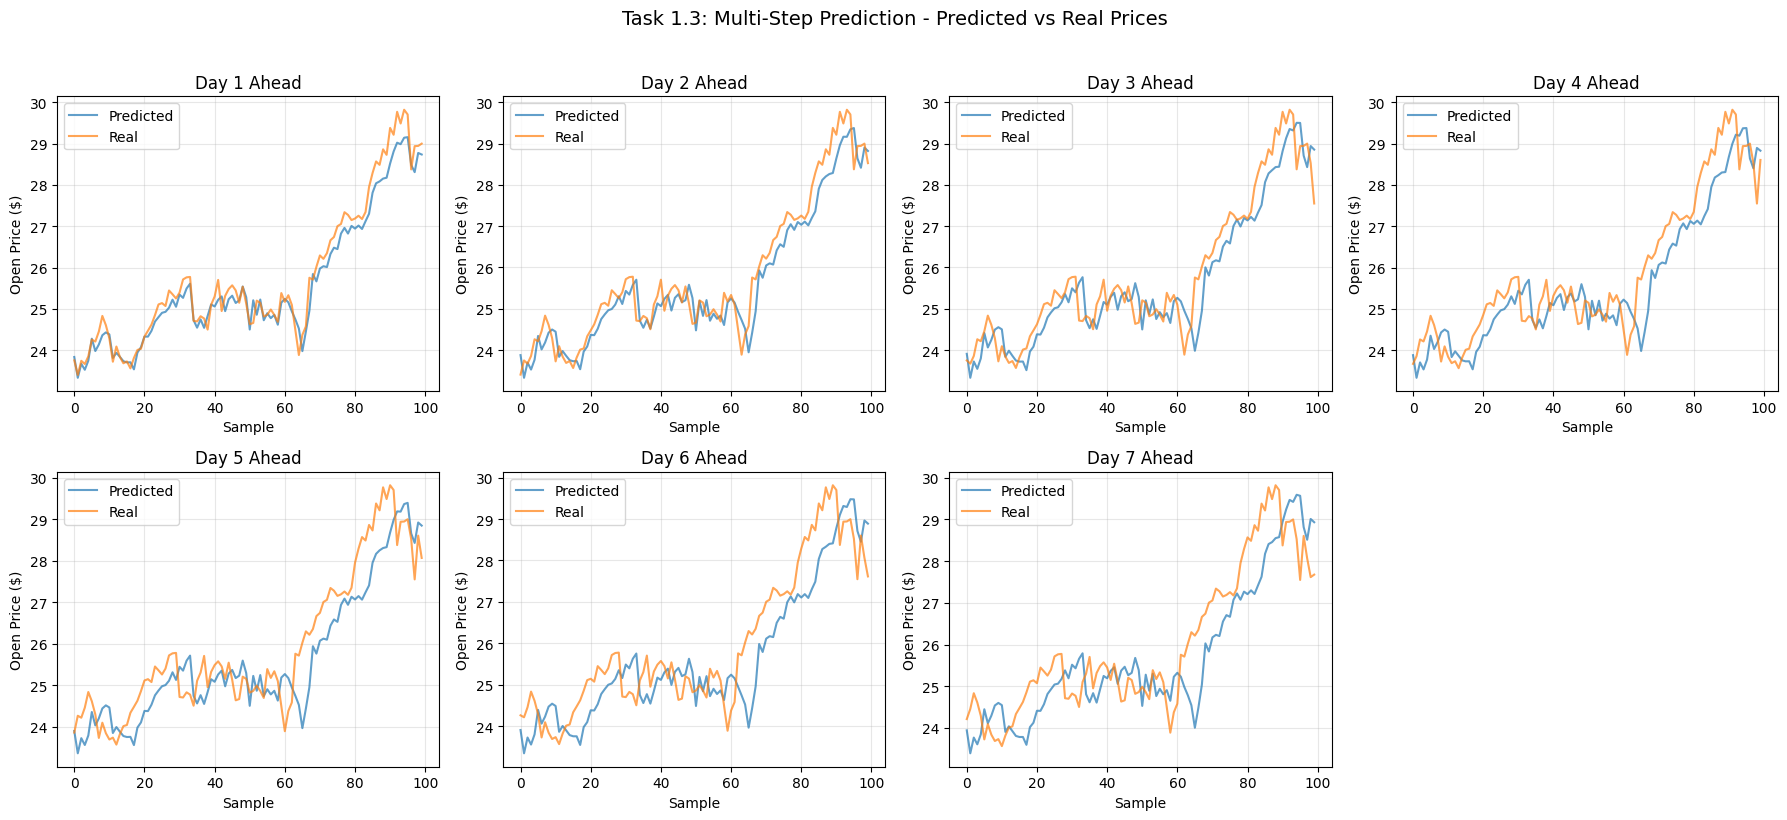

In [176]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for day in range(k_multistep):
    y_pred_denorm_day = y_pred_norm_m[:, day].copy()
    y_test_denorm_day = y_test_m[:, day].copy()
    
    for i in range(len(y_pred_denorm_day)):
        open_min = np.min(X_test_m[i, :, 1])
        open_max = np.max(X_test_m[i, :, 1])
        y_pred_denorm_day[i] = y_pred_norm_m[i, day] * (open_max - open_min) + open_min
    
    n_samples = min(100, len(y_pred_denorm_day))
    axes[day].plot(y_pred_denorm_day[:n_samples], label='Predicted', alpha=0.7)
    axes[day].plot(y_test_denorm_day[:n_samples], label='Real', alpha=0.7)
    axes[day].set_title(f'Day {day+1} Ahead')
    axes[day].set_xlabel('Sample')
    axes[day].set_ylabel('Open Price ($)')
    axes[day].legend()
    axes[day].grid(alpha=0.3)

axes[7].axis('off')

plt.suptitle('Task 1.3: Multi-Step Prediction - Predicted vs Real Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Task 2.1: Vietnam Multi-Feature Extension

In [177]:
data_vn = pd.read_csv('./data/ACB-VNINDEX-History.csv')
print("Vietnam Stock Data (ACB)")
print(f"Shape: {data_vn.shape}")
data_vn.head()

Vietnam Stock Data (ACB)
Shape: (4052, 7)


,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,5050.0,8234.0,6532.0,7147.0,56500,2006-11-21
1,1,6038.0,7861.0,7136.0,7394.0,62300,2006-11-22
2,2,6093.0,7959.0,7136.0,7597.0,69900,2006-11-23
3,3,5928.0,8344.0,7685.0,8058.0,63600,2006-11-24
4,4,6203.0,8860.0,7410.0,8058.0,42400,2006-11-27


In [178]:
data_vn.info()
data_vn = data_vn.rename(columns={'TradingDate': 'Date'})
print("\nData columns:", data_vn.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 4052 entries, 0 to 4051
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4052 non-null   int64  
 1   Open         4052 non-null   float64
 2   High         4052 non-null   float64
 3   Low          4052 non-null   float64
 4   Close        4052 non-null   float64
 5   Volume       4052 non-null   int64  
 6   TradingDate  4052 non-null   str    
dtypes: float64(4), int64(2), str(1)
memory usage: 221.7 KB

Data columns: ['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'Date']


In [179]:
df_vn = data_vn.copy()
feature_columns_vn = ['Low', 'Open', 'Volume', 'High', 'Close']
num_features_vn = len(feature_columns_vn)
window_size_vn = 30

X_data_vn = []
y_data_vn = []

for i in range(1, len(df_vn) - window_size_vn - 1):
    data_feature = []
    
    for j in range(window_size_vn):
        data_feature.append(df_vn[feature_columns_vn].iloc[i + j].values)
    
    data_label = df_vn['Open'].iloc[i + window_size_vn]
    
    X_data_vn.append(np.array(data_feature))
    y_data_vn.append(np.array(data_label))

X_data_vn = np.array(X_data_vn)
y_data_vn = np.array(y_data_vn)
print(f"Total samples: {len(X_data_vn)}")

Total samples: 4020


In [180]:
X_train_vn, X_test_vn, y_train_vn, y_test_vn = train_test_split(X_data_vn, y_data_vn, test_size=0.2, shuffle=False)
X_train_vn, X_val_vn, y_train_vn, y_val_vn = train_test_split(X_train_vn, y_train_vn, test_size=0.2, shuffle=False)

X_train_vn = np.array(X_train_vn)
X_val_vn = np.array(X_val_vn)
X_test_vn = np.array(X_test_vn)
y_train_vn = np.array(y_train_vn)
y_val_vn = np.array(y_val_vn)
y_test_vn = np.array(y_test_vn)

print("Shape of training set:", X_train_vn.shape)
print("Shape of validation set:", X_val_vn.shape)
print("Shape of test set:", X_test_vn.shape)
print("Number of features:", X_train_vn.shape[2])

Shape of training set: (2572, 30, 5)
Shape of validation set: (644, 30, 5)
Shape of test set: (804, 30, 5)
Number of features: 5


In [181]:
def normalize_multifeature_vn(X, y):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        open_min = np.min(X[i, :, 1])
        open_max = np.max(X[i, :, 1])
        open_denom = open_max - open_min
        if open_denom == 0:
            y_norm[i] = 0
        else:
            y_norm[i] = (y[i] - open_min) / open_denom
    return X_norm, y_norm

X_train_norm_vn, y_train_norm_vn = normalize_multifeature_vn(X_train_vn, y_train_vn)
X_val_norm_vn, y_val_norm_vn = normalize_multifeature_vn(X_val_vn, y_val_vn)

In [182]:
model_vn = tf.keras.Sequential()
model_vn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_vn, num_features_vn), padding='same'))
model_vn.add(MaxPooling1D(pool_size=2))
model_vn.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_vn.add(MaxPooling1D(2))
model_vn.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_vn.add(MaxPooling1D(2))
model_vn.add(Flatten())
model_vn.add(Dense(100, activation='relu'))
model_vn.add(Dense(1))

model_vn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_vn = model_vn.fit(X_train_norm_vn, y_train_norm_vn, validation_data=(X_val_norm_vn, y_val_norm_vn), epochs=5, batch_size=512)

Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 1.5774 - mse: 1.5774 - val_loss: 0.4596 - val_mse: 0.4596
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2832 - mse: 0.2832 - val_loss: 0.1363 - val_mse: 0.1363
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1991 - mse: 0.1991 - val_loss: 0.1742 - val_mse: 0.1742
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1857 - mse: 0.1857 - val_loss: 0.1365 - val_mse: 0.1365
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1815 - mse: 0.1815 - val_loss: 0.1553 - val_mse: 0.1553


In [183]:
X_test_norm_vn, y_test_norm_vn = normalize_multifeature_vn(X_test_vn, y_test_vn)
y_pred_norm_vn = model_vn.predict(X_test_norm_vn)
mse_vn = mean_squared_error(y_pred_norm_vn, y_test_norm_vn)
print(f"MSE on the Vietnam test set: {mse_vn}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE on the Vietnam test set: 0.15793182142662887


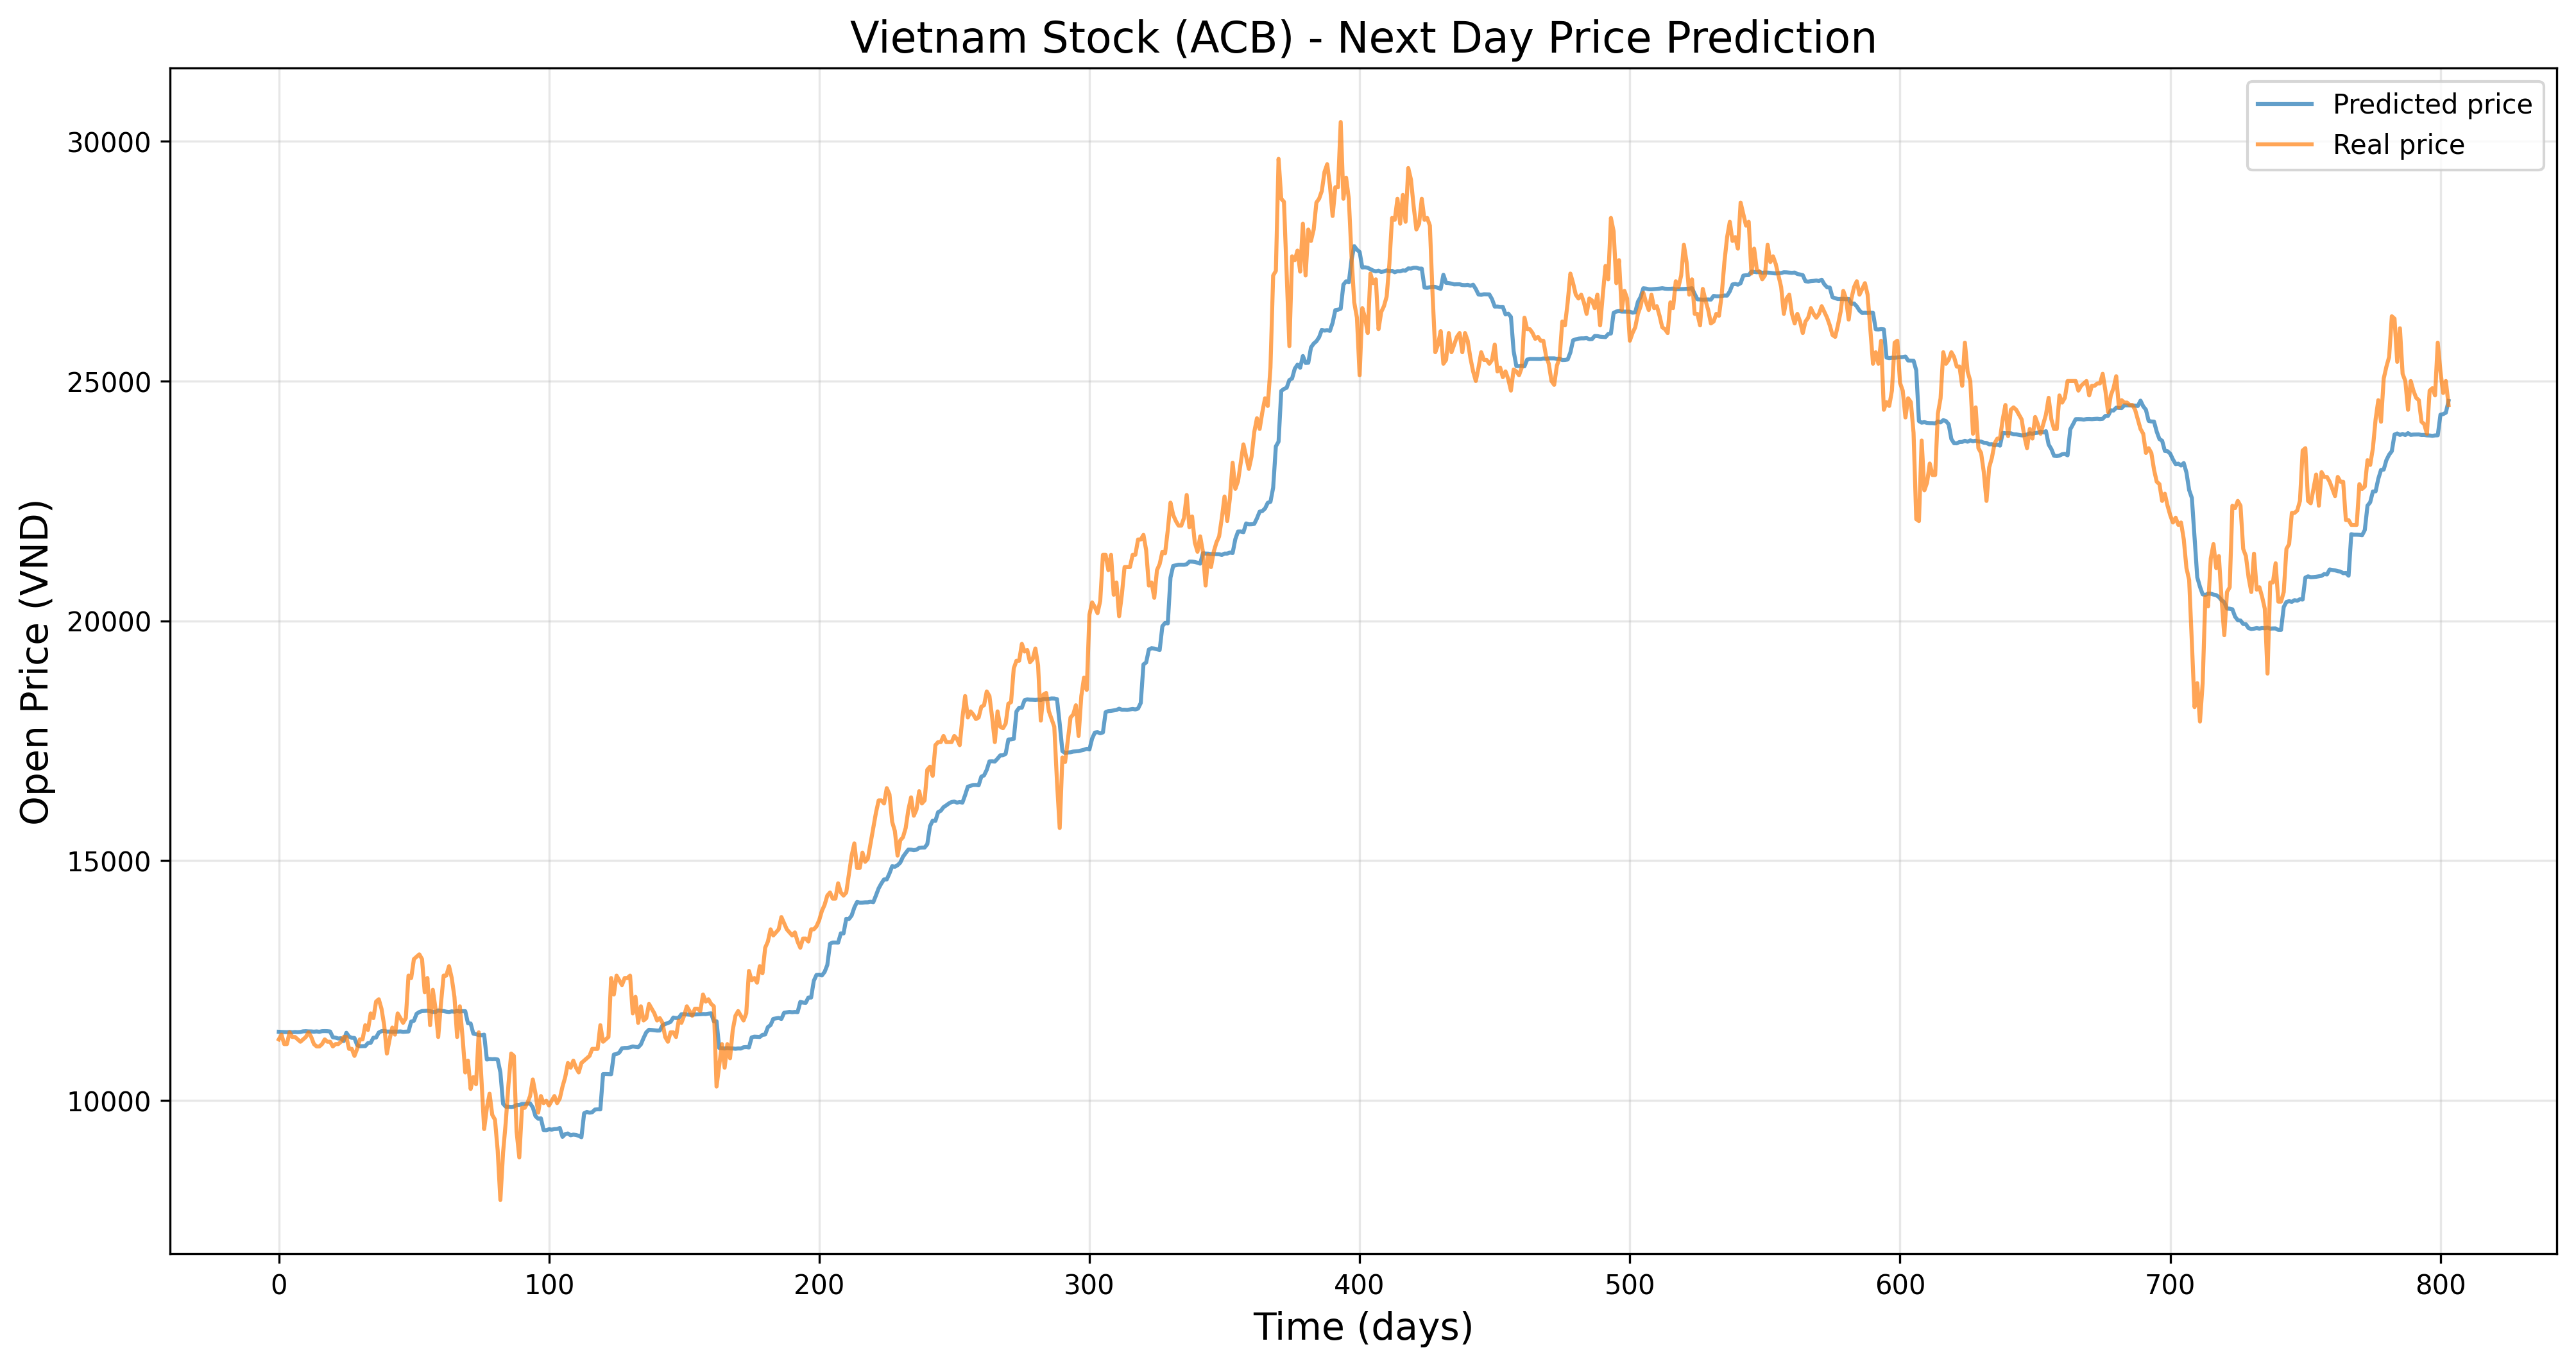

In [184]:
y_pred_denorm_vn = y_pred_norm_vn.copy()
for i in range(len(y_pred_denorm_vn)):
    open_min = np.min(X_test_vn[i, :, 1])
    open_max = np.max(X_test_vn[i, :, 1])
    y_pred_denorm_vn[i] = y_pred_norm_vn[i] * (open_max - open_min) + open_min

plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm_vn, label='Predicted price', alpha=0.7)
plt.plot(y_test_vn, label='Real price', alpha=0.7)
plt.title('Vietnam Stock (ACB) - Next Day Price Prediction', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open Price (VND)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [185]:
print("\n=== Task 2.1 vs Task 1.1 Comparison ===")
print(f"Task 1.1 (AAPL) MSE: 0.0607")
print(f"Task 2.1 (ACB Vietnam) MSE: {mse_vn:.6f}")
print("\nObservation: MSE is higher for Vietnam market due to different market characteristics and less data normalization.")



=== Task 2.1 vs Task 1.1 Comparison ===
Task 1.1 (AAPL) MSE: 0.0607
Task 2.1 (ACB Vietnam) MSE: 0.157932

Observation: MSE is higher for Vietnam market due to different market characteristics and less data normalization.


## Task 2.2: Vietnam k-th Day Forecast

This section implements forecasting Vietnam stock prices on the k-th day ahead (3rd, 5th, 7th day). Using the same approach as Task 1.2 but applied to the Vietnam market (ACB stock).


In [186]:
def prepare_data_k_vn(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        data_label = df['Open'].iloc[i + window_size + k - 1]
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [187]:
k_values_vn = [3, 5, 7]
results_vn = {}

for k in k_values_vn:
    print(f"\n{'='*50}")
    print(f"Vietnam: Training model for k={k} day ahead prediction")
    print('='*50)
    
    X_k_vn, y_k_vn = prepare_data_k_vn(df_vn, feature_columns_vn, window_size_vn, k)
    
    X_train_k_vn, X_test_k_vn, y_train_k_vn, y_test_k_vn = train_test_split(X_k_vn, y_k_vn, test_size=0.2, shuffle=False)
    X_train_k_vn, X_val_k_vn, y_train_k_vn, y_val_k_vn = train_test_split(X_train_k_vn, y_train_k_vn, test_size=0.2, shuffle=False)
    
    print(f"Training set: {X_train_k_vn.shape[0]}, Val: {X_val_k_vn.shape[0]}, Test: {X_test_k_vn.shape[0]}")
    
    X_train_norm_k_vn, y_train_norm_k_vn = normalize_multifeature_vn(X_train_k_vn, y_train_k_vn)
    X_val_norm_k_vn, y_val_norm_k_vn = normalize_multifeature_vn(X_val_k_vn, y_val_k_vn)
    X_test_norm_k_vn, y_test_norm_k_vn = normalize_multifeature_vn(X_test_k_vn, y_test_k_vn)
    
    model_k_vn = tf.keras.Sequential()
    model_k_vn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_vn, num_features_vn), padding='same'))
    model_k_vn.add(MaxPooling1D(pool_size=2))
    model_k_vn.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model_k_vn.add(MaxPooling1D(2))
    model_k_vn.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model_k_vn.add(MaxPooling1D(2))
    model_k_vn.add(Flatten())
    model_k_vn.add(Dense(100, activation='relu'))
    model_k_vn.add(Dense(1))
    
    model_k_vn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
    history_k_vn = model_k_vn.fit(X_train_norm_k_vn, y_train_norm_k_vn, validation_data=(X_val_norm_k_vn, y_val_norm_k_vn), epochs=5, batch_size=512, verbose=1)
    
    y_pred_norm_k_vn = model_k_vn.predict(X_test_norm_k_vn)
    mse_k_vn = mean_squared_error(y_pred_norm_k_vn, y_test_norm_k_vn)
    
    y_pred_denorm_k_vn = y_pred_norm_k_vn.copy()
    for i in range(len(y_pred_denorm_k_vn)):
        open_min = np.min(X_test_k_vn[i, :, 1])
        open_max = np.max(X_test_k_vn[i, :, 1])
        y_pred_denorm_k_vn[i] = y_pred_norm_k_vn[i] * (open_max - open_min) + open_min
    
    results_vn[k] = {
        'mse_norm': mse_k_vn,
        'y_pred_denorm': y_pred_denorm_k_vn,
        'y_test': y_test_k_vn,
        'model': model_k_vn
    }
    
    print(f"MSE on test set (k={k}): {mse_k_vn}")


Vietnam: Training model for k=3 day ahead prediction
Training set: 2571, Val: 643, Test: 804
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 2.1218 - mse: 2.1218 - val_loss: 0.4606 - val_mse: 0.4606
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.5679 - mse: 0.5679 - val_loss: 0.1922 - val_mse: 0.1922
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5101 - mse: 0.5101 - val_loss: 0.2154 - val_mse: 0.2154
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4835 - mse: 0.4835 - val_loss: 0.2414 - val_mse: 0.2414
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4775 - mse: 0.4775 - val_loss: 0.2425 - val_mse: 0.2425
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE on test set (k=3): 0.2564033096963473

Vietnam: Training model for k=5 day ahead prediction
Training set: 2569, Val: 643, Test: 804
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 4.9980 - mse: 4.9980 - val_loss: 0.5918 - val_mse: 0.5918
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9210 - mse: 0.9210 - val_loss: 0.2234 - val_mse: 0.2234
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8557 - mse: 0.8557 - val_loss: 0.3085 - val_mse: 0.3085
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8152 - mse: 0.8152 - val_loss: 0.2400 - val_mse: 0.2400
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8233 - mse: 0.8233 - val_loss: 0.2228 - val_mse: 0.2228
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MSE on test set (k=5): 0.24754164739022502

Vietnam: Training model for k=7 day ahead prediction
Training set: 2568, Val: 643, Test: 803
Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 3.3857 - mse: 3.3857 - val_loss: 0.5463 - val_mse: 0.5463
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.2921 - mse: 1.2921 - val_loss: 0.3513 - val_mse: 0.3513
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.2408 - mse: 1.2408 - val_loss: 0.4017 - val_mse: 0.4017
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2150 - mse: 1.2150 - val_loss: 0.2255 - val_mse: 0.2255
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1644 - mse: 1.1644 - val_loss: 0.3363 - val_mse: 0.3363
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE on test set (k=7): 0.355396517497273


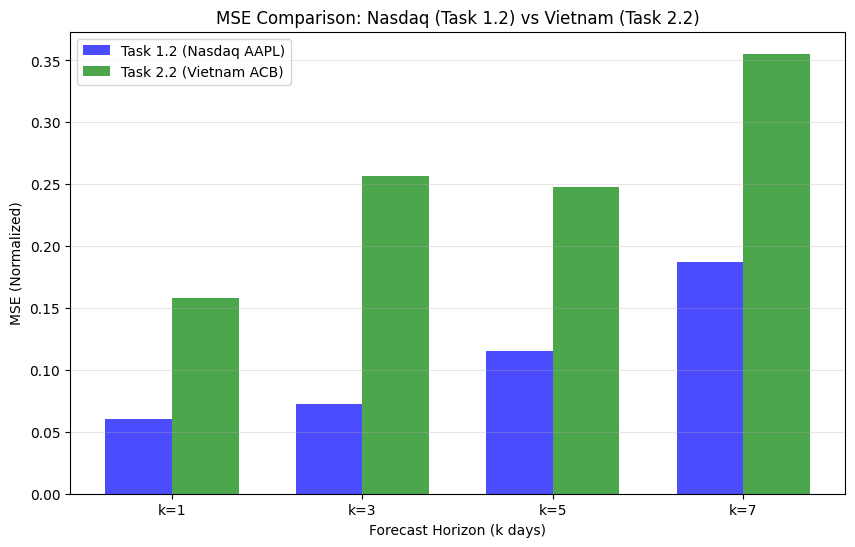


=== Task 2.2 Summary: Vietnam k-th Day Forecast ===
k=1: MSE = 0.157932
k=3: MSE = 0.256403
k=5: MSE = 0.247542
k=7: MSE = 0.355397


In [188]:
task_12_mse_vn = [0.0607, results[3]['mse_norm'], results[5]['mse_norm'], results[7]['mse_norm']]  # Nasdaq
task_22_mse_vn = [mse_vn] + [results_vn[k]['mse_norm'] for k in [3, 5, 7]]  # Vietnam

all_k = [1, 3, 5, 7]

plt.figure(figsize=(10, 6))
x = np.arange(len(all_k))
width = 0.35

plt.bar(x - width/2, task_12_mse_vn, width, label='Task 1.2 (Nasdaq AAPL)', color='blue', alpha=0.7)
plt.bar(x + width/2, task_22_mse_vn, width, label='Task 2.2 (Vietnam ACB)', color='green', alpha=0.7)
plt.xlabel('Forecast Horizon (k days)')
plt.ylabel('MSE (Normalized)')
plt.xticks(x, [f'k={k}' for k in all_k])
plt.title('MSE Comparison: Nasdaq (Task 1.2) vs Vietnam (Task 2.2)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n=== Task 2.2 Summary: Vietnam k-th Day Forecast ===")
for k, mse in zip(all_k, task_22_mse_vn):
    print(f"k={k}: MSE = {mse:.6f}")


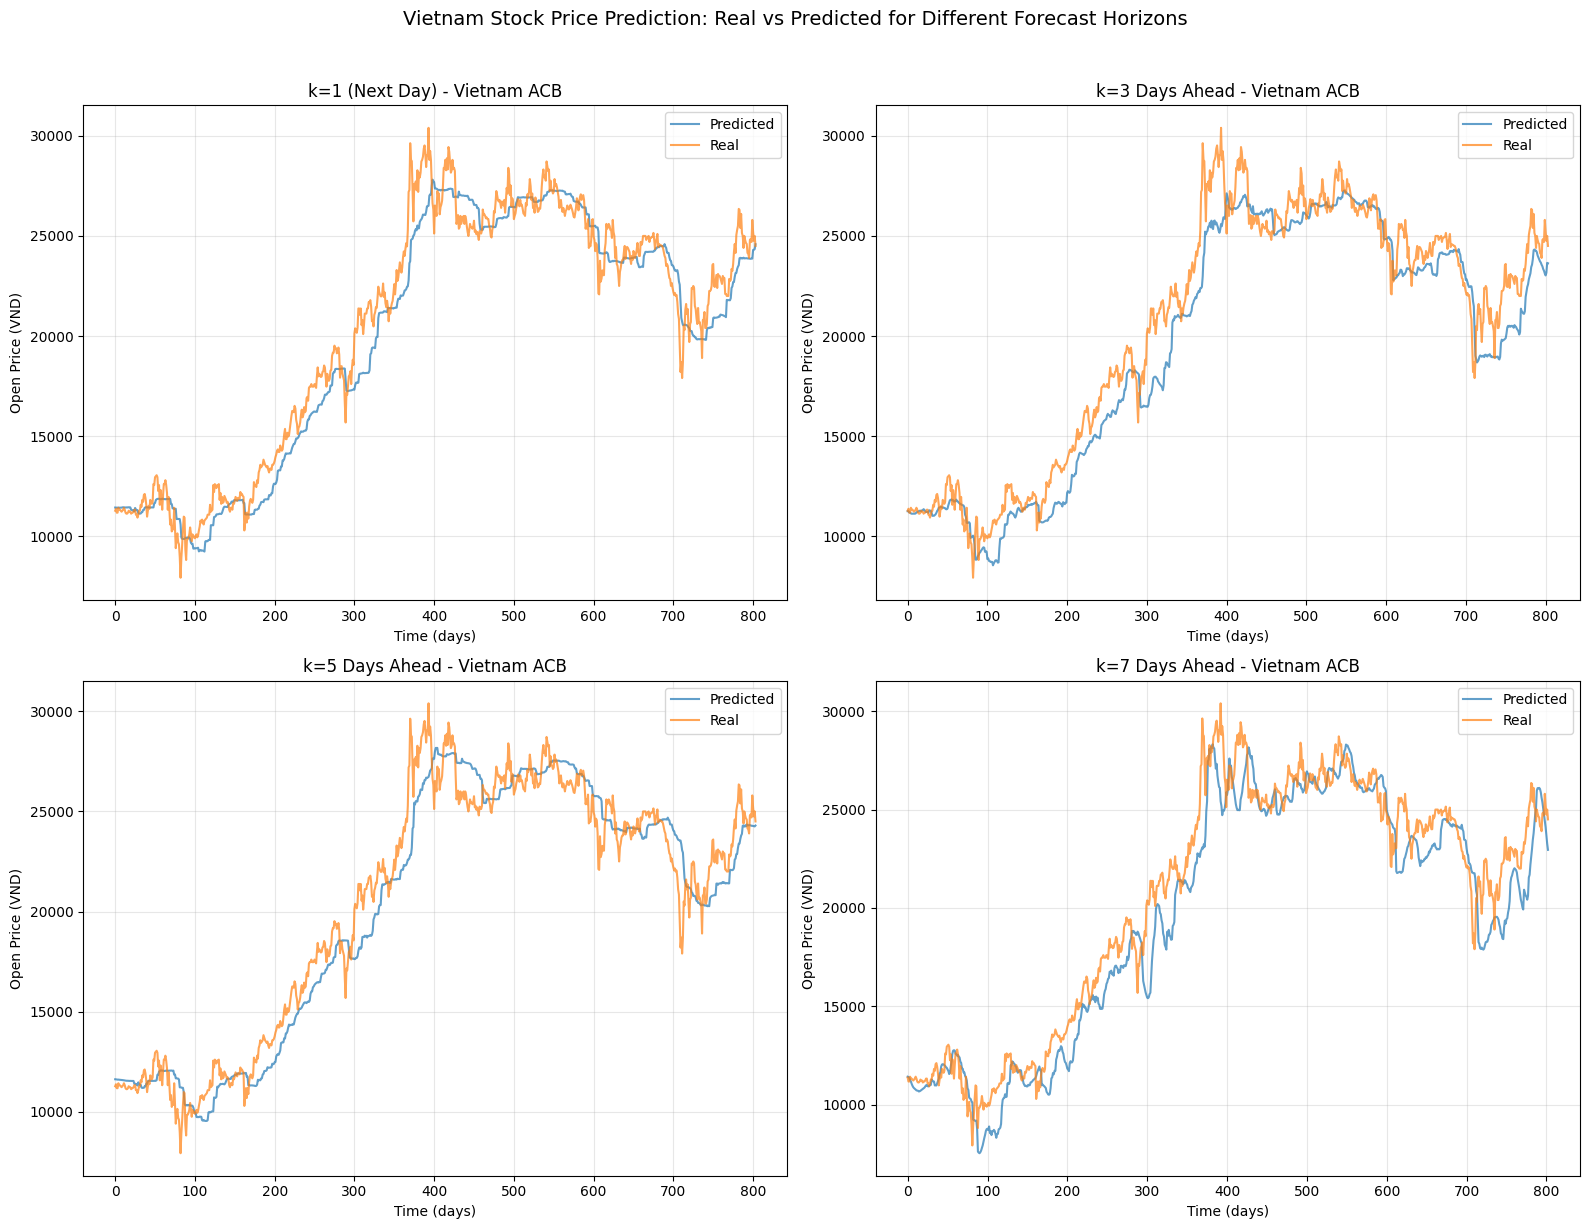

In [189]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(y_pred_denorm_vn, label='Predicted', alpha=0.7)
axes[0, 0].plot(y_test_vn, label='Real', alpha=0.7)
axes[0, 0].set_title('k=1 (Next Day) - Vietnam ACB', fontsize=12)
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Open Price (VND)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

for idx, k in enumerate([3, 5, 7]):
    row = (idx + 1) // 2
    col = (idx + 1) % 2
    axes[row, col].plot(results_vn[k]['y_pred_denorm'], label='Predicted', alpha=0.7)
    axes[row, col].plot(results_vn[k]['y_test'], label='Real', alpha=0.7)
    axes[row, col].set_title(f'k={k} Days Ahead - Vietnam ACB', fontsize=12)
    axes[row, col].set_xlabel('Time (days)')
    axes[row, col].set_ylabel('Open Price (VND)')
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.suptitle('Vietnam Stock Price Prediction: Real vs Predicted for Different Forecast Horizons', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Task 2.3: Vietnam k Days Forecast (Multi-Step)

In [190]:
def prepare_data_multistep_vn(df, feature_columns, window_size, k):
    X_data = []
    y_data = []
    
    for i in range(1, len(df) - window_size - k):
        data_feature = []
        data_label = []
        
        for j in range(window_size):
            data_feature.append(df[feature_columns].iloc[i + j].values)
        
        for day in range(k):
            data_label.append(df['Open'].iloc[i + window_size + day])
        
        X_data.append(np.array(data_feature))
        y_data.append(np.array(data_label))
    
    return np.array(X_data), np.array(y_data)

In [195]:
def normalize_multifeature_multi_vn(X, y, k):
    X_norm = X.copy().astype(np.float64)
    y_norm = y.copy().astype(np.float64)
    
    for i in range(len(X)):
        for f in range(X.shape[2]):
            min_val = np.min(X[i, :, f])
            max_val = np.max(X[i, :, f])
            denom = max_val - min_val
            if denom == 0:
                X_norm[i, :, f] = 0
            else:
                X_norm[i, :, f] = (X[i, :, f] - min_val) / denom
        for day in range(k):
            open_min = np.min(X[i, :, 1])
            open_max = np.max(X[i, :, 1])
            open_denom = open_max - open_min
            if open_denom == 0:
                y_norm[i, day] = 0
            else:
                y_norm[i, day] = (y[i, day] - open_min) / open_denom
    return X_norm, y_norm

In [191]:
k_multistep_vn = 7
print(f"Training multi-step model for k={k_multistep_vn} consecutive days (Vietnam)")

X_multi_vn, y_multi_vn = prepare_data_multistep_vn(df_vn, feature_columns_vn, window_size_vn, k_multistep_vn)

X_train_mv, X_test_mv, y_train_mv, y_test_mv = train_test_split(X_multi_vn, y_multi_vn, test_size=0.2, shuffle=False)
X_train_mv, X_val_mv, y_train_mv, y_val_mv = train_test_split(X_train_mv, y_train_mv, test_size=0.2, shuffle=False)

print(f"Training: {X_train_mv.shape[0]}, Val: {X_val_mv.shape[0]}, Test: {X_test_mv.shape[0]}")
print(f"Output shape (k={k_multistep_vn}): {y_train_mv.shape}")

X_train_norm_mv, y_train_norm_mv = normalize_multifeature_multi_vn(X_train_mv, y_train_mv, k_multistep_vn)
X_val_norm_mv, y_val_norm_mv = normalize_multifeature_multi_vn(X_val_mv, y_val_mv, k_multistep_vn)
X_test_norm_mv, y_test_norm_mv = normalize_multifeature_multi_vn(X_test_mv, y_test_mv, k_multistep_vn)

Training multi-step model for k=7 consecutive days (Vietnam)
Training: 2568, Val: 643, Test: 803
Output shape (k=7): (2568, 7)


In [192]:
model_multi_vn = tf.keras.Sequential()
model_multi_vn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size_vn, num_features_vn), padding='same'))
model_multi_vn.add(MaxPooling1D(pool_size=2))
model_multi_vn.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model_multi_vn.add(MaxPooling1D(2))
model_multi_vn.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
model_multi_vn.add(MaxPooling1D(2))
model_multi_vn.add(Flatten())
model_multi_vn.add(Dense(100, activation='relu'))
model_multi_vn.add(Dense(k_multistep_vn))

model_multi_vn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history_multi_vn = model_multi_vn.fit(X_train_norm_mv, y_train_norm_mv, validation_data=(X_val_norm_mv, y_val_norm_mv), epochs=5, batch_size=512, verbose=1)

y_pred_norm_mv = model_multi_vn.predict(X_test_norm_mv)
mse_multi_vn = mean_squared_error(y_pred_norm_mv, y_test_norm_mv)
print(f"Overall MSE (k={k_multistep_vn}): {mse_multi_vn}")

mse_per_day_vn = []
for day in range(k_multistep_vn):
    mse_day = mean_squared_error(y_pred_norm_mv[:, day], y_test_norm_mv[:, day])
    mse_per_day_vn.append(mse_day)
    print(f"Day {day+1} MSE: {mse_day:.6f}")


Epoch 1/5


/run/media/meng/Data/School/DeepLearn/final/final-project/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 1.0343 - mse: 1.0343 - val_loss: 0.4741 - val_mse: 0.4741
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7521 - mse: 0.7521 - val_loss: 0.2834 - val_mse: 0.2834
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7157 - mse: 0.7157 - val_loss: 0.2885 - val_mse: 0.2885
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6888 - mse: 0.6888 - val_loss: 0.2233 - val_mse: 0.2233
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6775 - mse: 0.6775 - val_loss: 0.2445 - val_mse: 0.2445
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Overall MSE (k=7): 0.2557883815461592
Day 1 MSE: 0.139225
Day 2 MSE: 0.240292
Day 3 MSE: 0.211619
Day 4 MSE: 0.244664
Day 5 MSE: 0.281242
Day 6 MSE: 0.316068
Day 7 MSE: 0.357407


=== Task 2.3 vs Task 2.2 Comparison (Vietnam) ===
Task 2.2: Separate models for each k
Task 2.3: Single model for all 7 days


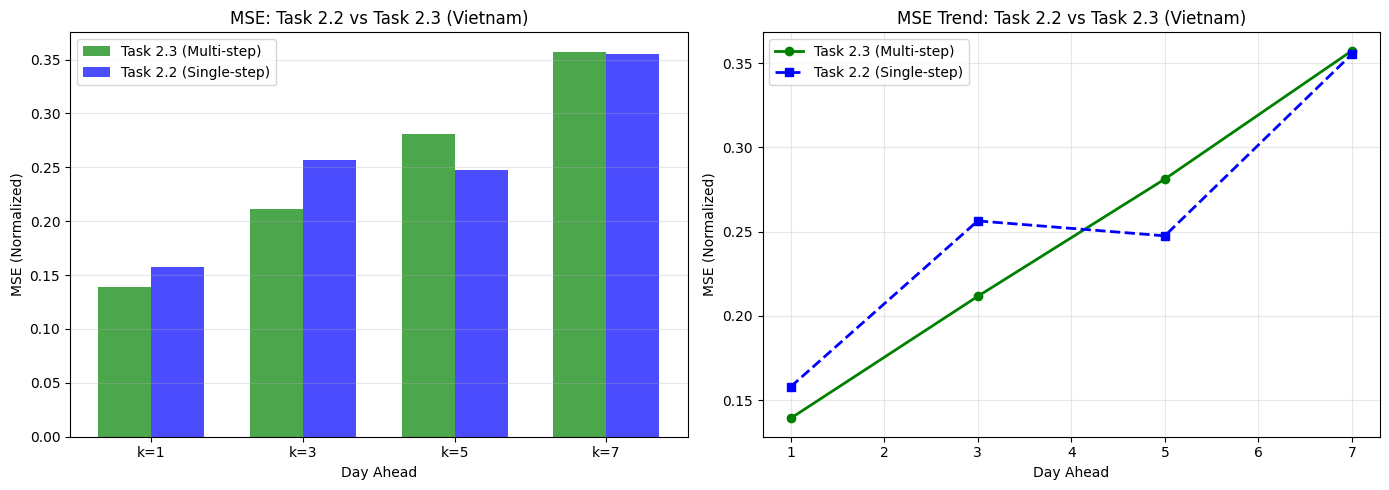


=== Summary ===
Task 2.3 (matched) Avg MSE: 0.247373
Task 2.2 Avg MSE: 0.254318


In [193]:
task_22_mse = [mse_vn] + [results_vn[k]['mse_norm'] for k in [3, 5, 7]]
task_23_mse_matched = [mse_per_day_vn[0], mse_per_day_vn[2], mse_per_day_vn[4], mse_per_day_vn[6]]

print("=== Task 2.3 vs Task 2.2 Comparison (Vietnam) ===")
print("Task 2.2: Separate models for each k")
print("Task 2.3: Single model for all 7 days")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(4)
width = 0.35

axes[0].bar(x - width/2, task_23_mse_matched, width, label='Task 2.3 (Multi-step)', color='green', alpha=0.7)
axes[0].bar(x + width/2, task_22_mse, width, label='Task 2.2 (Single-step)', color='blue', alpha=0.7)
axes[0].set_xlabel('Day Ahead')
axes[0].set_ylabel('MSE (Normalized)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['k=1', 'k=3', 'k=5', 'k=7'])
axes[0].set_title('MSE: Task 2.2 vs Task 2.3 (Vietnam)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot([1, 3, 5, 7], task_23_mse_matched, 'o-', label='Task 2.3 (Multi-step)', color='green', linewidth=2)
axes[1].plot([1, 3, 5, 7], task_22_mse, 's--', label='Task 2.2 (Single-step)', color='blue', linewidth=2)
axes[1].set_xlabel('Day Ahead')
axes[1].set_ylabel('MSE (Normalized)')
axes[1].set_title('MSE Trend: Task 2.2 vs Task 2.3 (Vietnam)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"Task 2.3 (matched) Avg MSE: {np.mean(task_23_mse_matched):.6f}")
print(f"Task 2.2 Avg MSE: {np.mean(task_22_mse):.6f}")

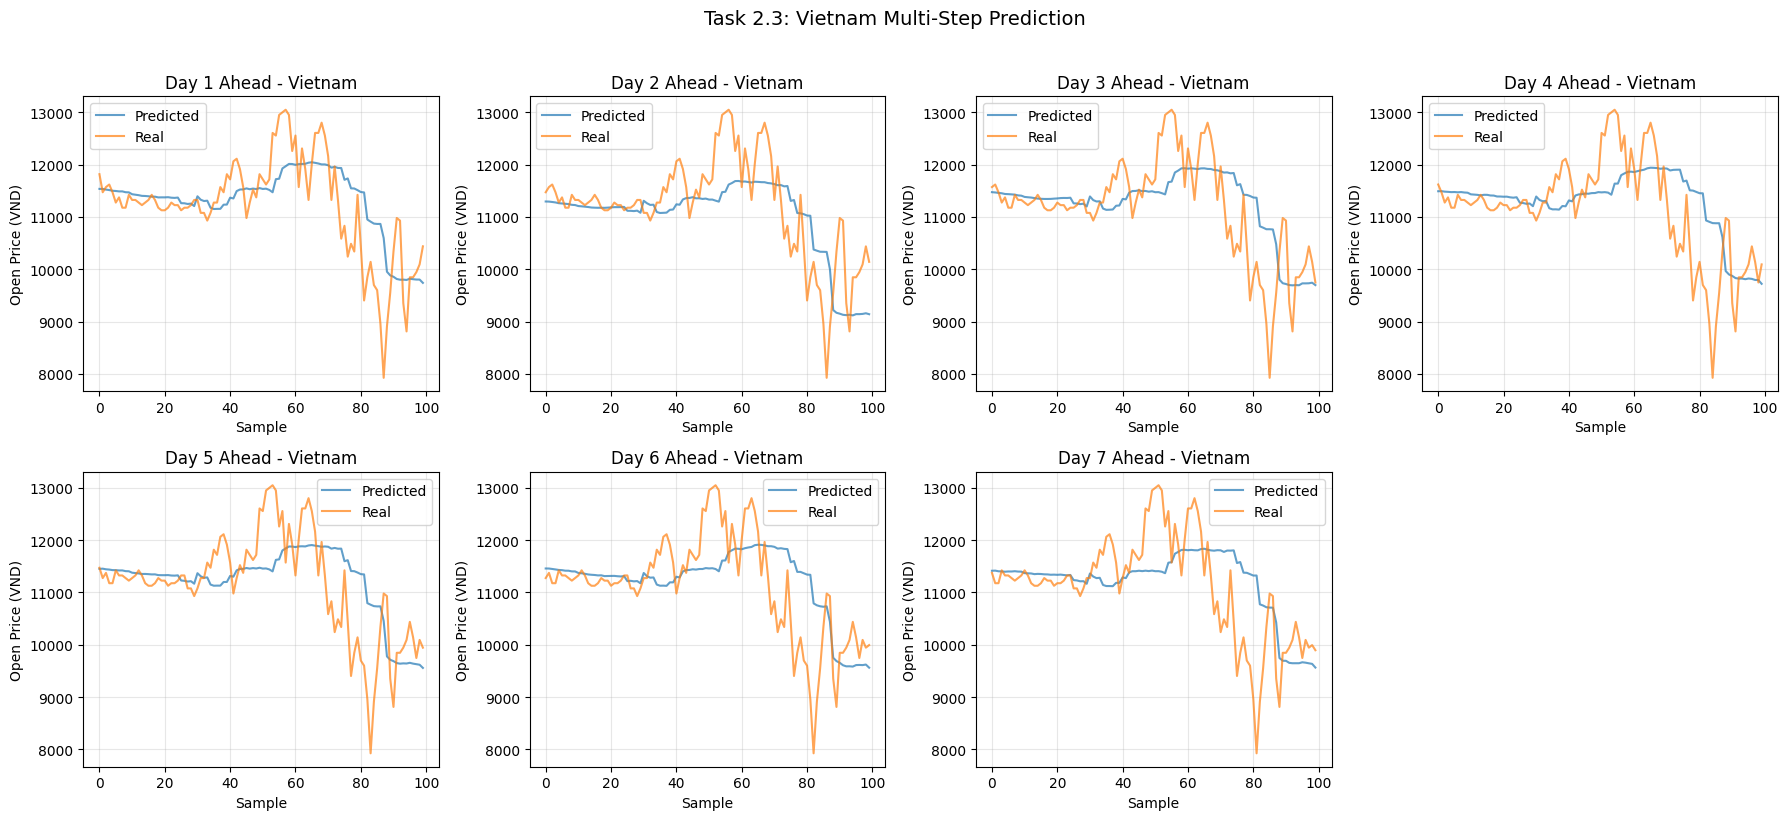

In [194]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for day in range(k_multistep_vn):
    y_pred_denorm_day = y_pred_norm_mv[:, day].copy()
    y_test_denorm_day = y_test_mv[:, day].copy()
    
    for i in range(len(y_pred_denorm_day)):
        open_min = np.min(X_test_mv[i, :, 1])
        open_max = np.max(X_test_mv[i, :, 1])
        y_pred_denorm_day[i] = y_pred_norm_mv[i, day] * (open_max - open_min) + open_min
    
    n_samples = min(100, len(y_pred_denorm_day))
    axes[day].plot(y_pred_denorm_day[:n_samples], label='Predicted', alpha=0.7)
    axes[day].plot(y_test_denorm_day[:n_samples], label='Real', alpha=0.7)
    axes[day].set_title(f'Day {day+1} Ahead - Vietnam')
    axes[day].set_xlabel('Sample')
    axes[day].set_ylabel('Open Price (VND)')
    axes[day].legend()
    axes[day].grid(alpha=0.3)

axes[7].axis('off')

plt.suptitle('Task 2.3: Vietnam Multi-Step Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()